# Model Analysis - Livestock Health Triage Classifier

Quick exploratory look at the synthetic dataset and the trained model's behaviour. Run `python src/data_generator.py` and `python src/train_model.py` from the project root before running this notebook.

**Note:** the dataset is entirely synthetic - see the project README.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from src import config, preprocessing, risk_scoring

reports = pd.read_csv(config.REPORTS_CSV)
regions = pd.read_csv(config.REGIONS_CSV)
model = joblib.load(config.MODEL_PATH)
preprocessor = joblib.load(config.PREPROCESSOR_PATH)
reports.shape, regions.shape

((5405, 25), (90, 5))

## 1. Class balance in the synthetic dataset

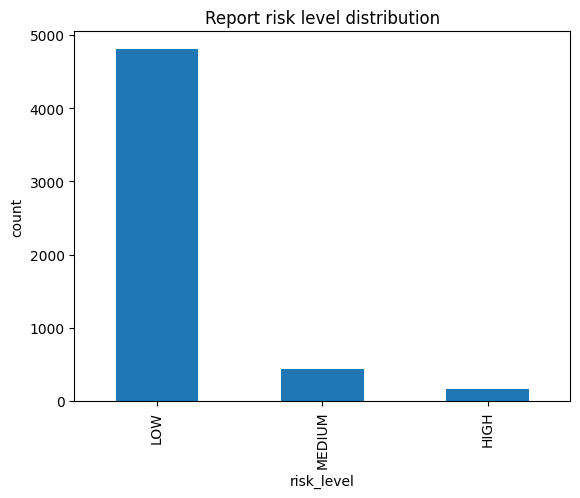

In [2]:
reports['risk_level'].value_counts().plot(kind='bar', title='Report risk level distribution')
plt.ylabel('count')
plt.show()

## 2. Confusion matrix on a held-out split

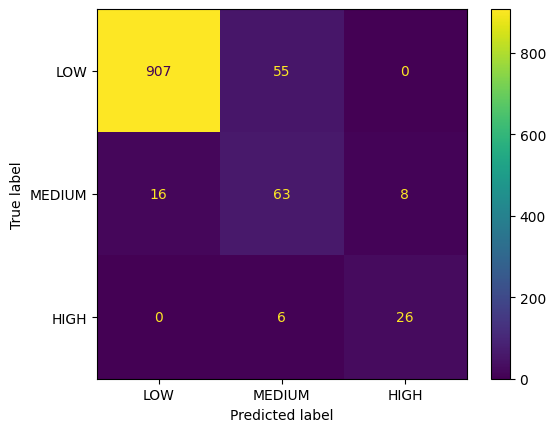

In [3]:
from sklearn.model_selection import train_test_split

engineered = preprocessing.engineer_features(reports, add_context=True)
X = preprocessing.to_feature_frame(engineered)
y = engineered['risk_level']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=config.RANDOM_SEED, stratify=y,
)
X_test_t = preprocessor.transform(X_test)
y_pred = model.predict(X_test_t)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=config.RISK_LEVELS)
plt.show()

## 3. Feature importances

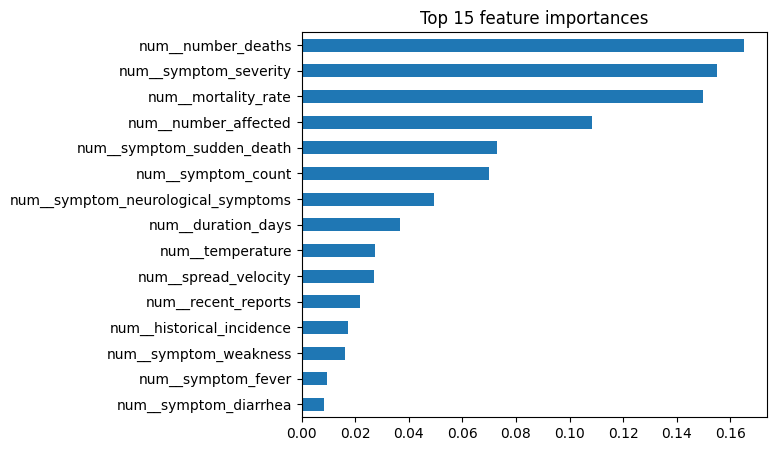

In [4]:
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(6, 5))
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances')
plt.show()

## 4. Regional risk score distribution (as of the latest date in the data)

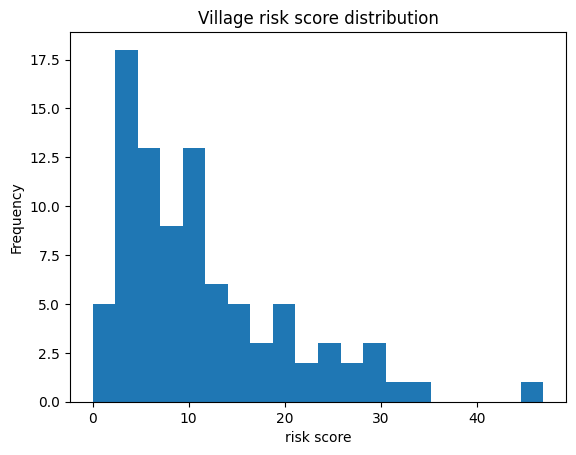

,village,report_count_7d,report_count_30d,affected_animals,deaths,mortality_rate,high_concern_count,high_concern_ratio,report_growth_rate,historical_incidence,risk_score,risk_category,sub_score_volume,sub_score_growth,sub_score_mortality,sub_score_high_concern,sub_score_historical
0,Sambhajinagar Block-2 Village-5,4,8,23,8,0.3478,1,0.25,4.0000,2,46.9,MEDIUM,20.0,100.0,69.6,25.0,20.0
1,Amravati Block-2 Village-2,8,19,18,0,0.0000,0,0.00,4.0000,2,33.0,MEDIUM,40.0,100.0,0.0,0.0,20.0
2,Nashik Block-3 Village-2,4,18,19,1,0.0526,0,0.00,4.0000,3,31.6,MEDIUM,20.0,100.0,10.5,0.0,30.0
3,Nashik Block-2 Village-3,4,14,19,1,0.0526,0,0.00,4.0000,1,28.6,LOW,20.0,100.0,10.5,0.0,10.0
4,Nashik Block-2 Village-4,9,20,32,3,0.0938,0,0.00,3.0000,0,28.3,LOW,45.0,66.7,18.8,0.0,0.0
5,Sambhajinagar Block-3 Village-1,5,16,16,0,0.0000,0,0.00,2.5000,8,28.2,LOW,25.0,50.0,0.0,0.0,80.0
6,Kolhapur Block-1 Village-3,4,11,15,0,0.0000,0,0.00,4.0000,2,28.0,LOW,20.0,100.0,0.0,0.0,20.0
7,Kolhapur Block-2 Village-4,2,14,26,7,0.2692,1,0.50,0.6667,3,27.8,LOW,10.0,0.0,53.8,50.0,30.0
8,Nagpur Block-2 Village-5,6,16,16,1,0.0625,0,0.00,2.0000,6,25.7,LOW,30.0,33.3,12.5,0.0,60.0
9,Pune Block-2 Village-3,4,38,25,5,0.2000,0,0.00,0.3636,8,25.0,LOW,20.0,0.0,40.0,0.0,80.0


In [5]:
village_risk = risk_scoring.calculate_village_risk(reports)
village_risk['risk_score'].plot(kind='hist', bins=20, title='Village risk score distribution')
plt.xlabel('risk score')
plt.show()

village_risk.head(10)